In [ ]:
# 3rd August, 2026
# Learned Decision Tree Implementation

# 1. Import the libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 2. Load the dataset

In [6]:
data = load_breast_cancer()
X = data.data
y = data.target
print("Features:", X.shape)
print("Target:", y.shape)

Features: (569, 30)
Target: (569,)


In [7]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [4]:
data.target # our objective is to predict whether cancer is benign or malignant
# Here, all data pre-processing is already done, so we don't need to do pre-processing for this dataset

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

# 3. Create train test split

In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [11]:
# train full tree without plotting
full_tree=DecisionTreeClassifier(max_depth=None,random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [14]:
#predictions
y_train_pred=full_tree.predict(X_train)
y_test_pred=full_tree.predict(X_test)
print('Train accuracy:',accuracy_score(y_train,y_train_pred))
print('Test accuracy:',accuracy_score(y_test,y_test_pred))

Train accuracy: 1.0
Test accuracy: 0.9473684210526315


In [ ]:
# This 'Train Accuracy = 1' means it is a condition of overfitting
# This is mild form of accuracy
# Why This Is Overfitting
# A training accuracy of 1.0 means the model memorized every single training example.
# A test accuracy of 0.95 means it still generalizes very well to new data.
# The small gap (5%) means the overfitting is not severe

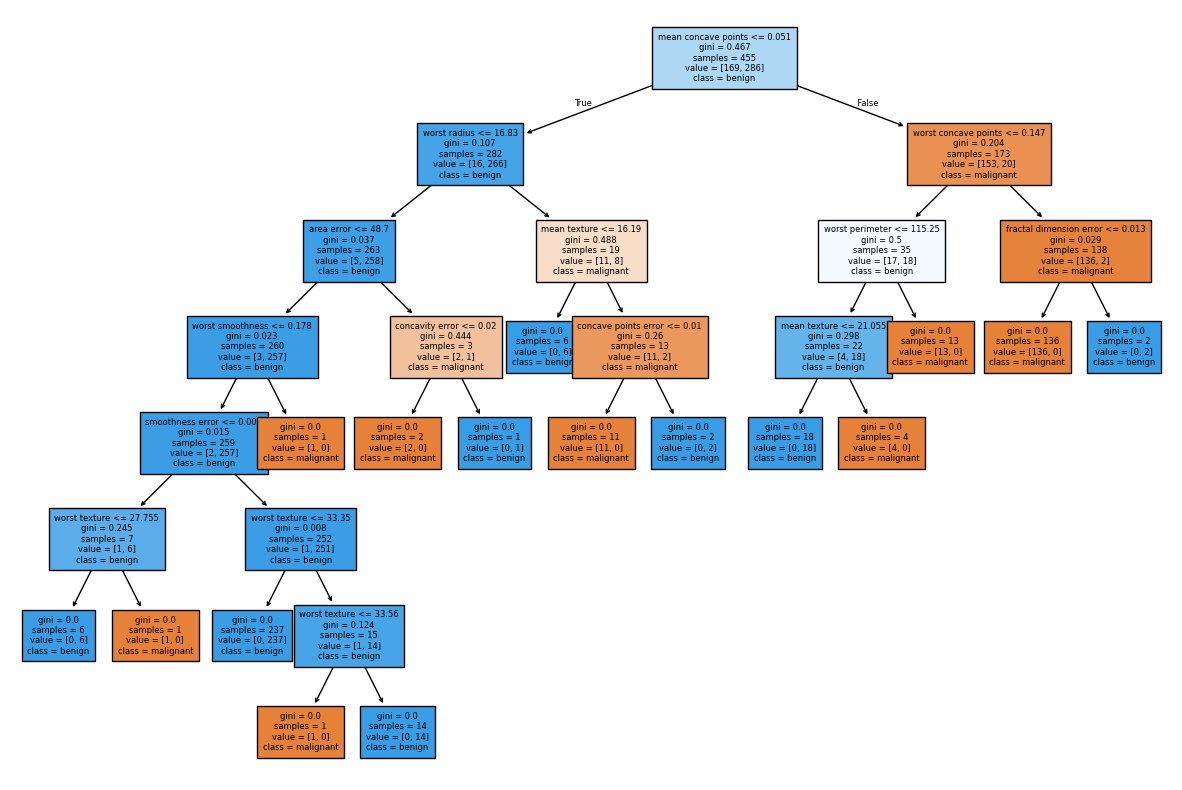

In [16]:
plt.figure(figsize=(15,10))
plot_tree(full_tree,filled=True,feature_names=data.feature_names,class_names=data.target_names,fontsize=6)
plt.show()

In [ ]:
# Lets solve this problem of this overfititng using: 1. Early Stopping 2. Pruning

# Solution 1: Early Stopping

In [21]:
pre_tree=DecisionTreeClassifier(max_depth=3,
                                min_samples_split=10,
                                min_samples_leaf=5,
                                random_state=42)
# choose these hyperparameters yourself
pre_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [22]:
# predictions on this new Decision Tree
y_train_pred=pre_tree.predict(X_train)
y_test_pred=pre_tree.predict(X_test)
print('Train accuracy:',accuracy_score(y_train,y_train_pred))
print('Test accuracy:',accuracy_score(y_test,y_test_pred))

Train accuracy: 0.9714285714285714
Test accuracy: 0.9473684210526315


In [23]:
# train accuracy = 0.92 and test accuracy = 0.89 means that overfitting is solved by Early Stopping

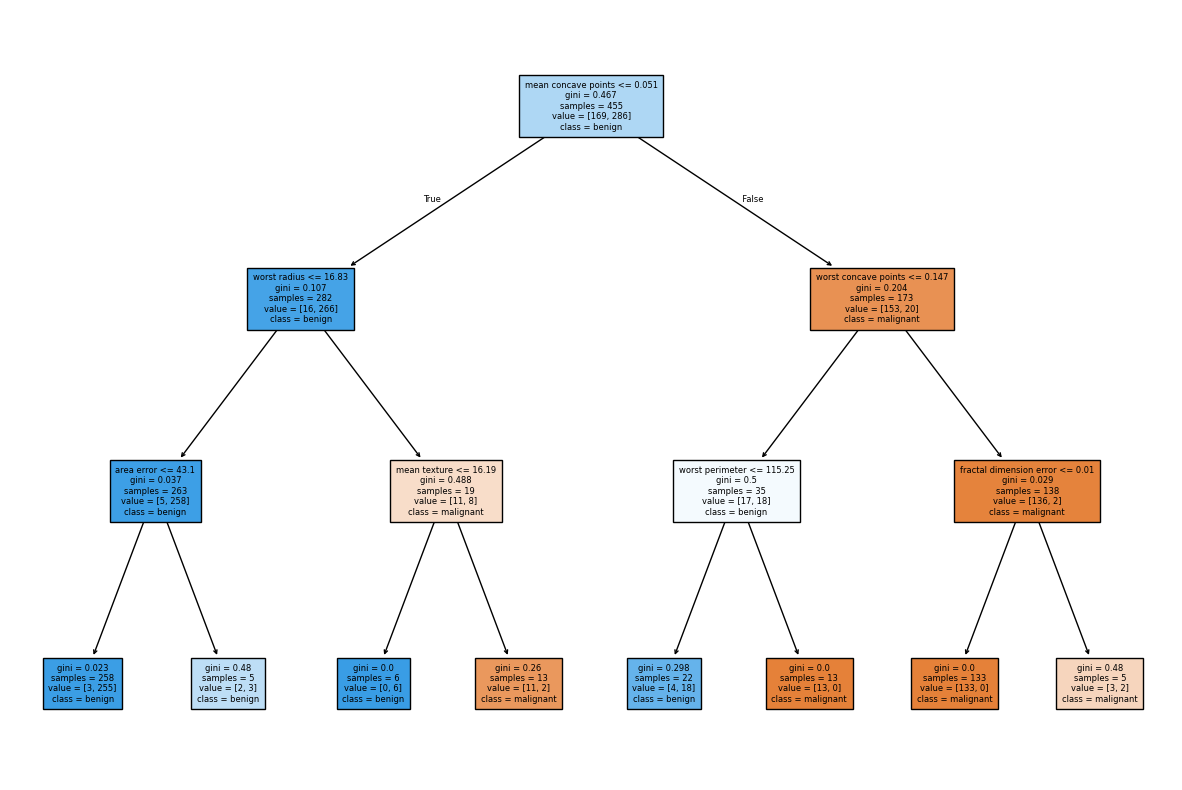

In [24]:
plt.figure(figsize=(15,10))
plot_tree(pre_tree,filled=True,feature_names=data.feature_names,class_names=data.target_names,fontsize=6)
plt.show()

# Solution 2: Pruning(Cost-complexity Pruning)

In [30]:
# finding the value of alpha
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas
print(alphas)

[0.         0.00218083 0.0029304  0.00431133 0.00559513 0.00743872
 0.0086638  0.01291987 0.01438561 0.02404453 0.02442056 0.0306549
 0.3228506 ]


In [31]:
# train trees for every value of alphas
train_scores=[]
test_scores=[]
for alpha in alphas:
  tree=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
  tree.fit(X_train,y_train)
  train_scores.append(tree.score(X_train,y_train))
  test_scores.append(tree.score(X_test,y_test))

Text(0, 0.5, 'accuracy')

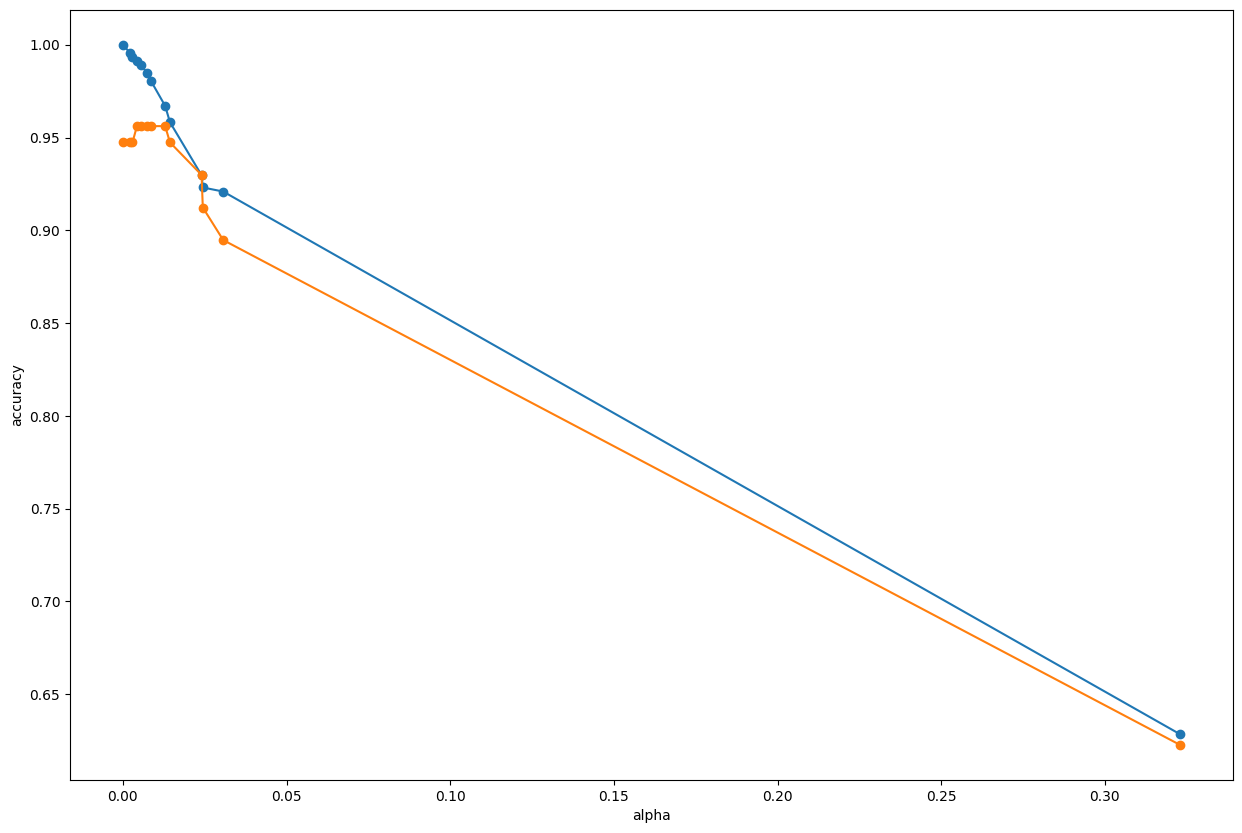

In [32]:
#choose alpha where testing accuracy is max

plt.figure(figsize=(15,10))
plt.plot(alphas,train_scores,marker='o',label='train')
plt.plot(alphas,test_scores,marker='o',label='test')
plt.xlabel('alpha')
plt.ylabel('accuracy')

In [33]:
best_alpha=alphas[np.argmax(test_scores)]
print('Best alpha:',best_alpha)

Best alpha: 0.004311334641004935


In [34]:
post_tree=DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)
post_tree.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.004311334641004935),
                       random_state=42)

In [36]:
# predictions on post Tree after pruning
y_train_pred=post_tree.predict(X_train)
y_test_pred=post_tree.predict(X_test)
print('Train accuracy:',accuracy_score(y_train,y_train_pred))
print('Test accuracy:',accuracy_score(y_test,y_test_pred))

Train accuracy: 0.9912087912087912
Test accuracy: 0.956140350877193


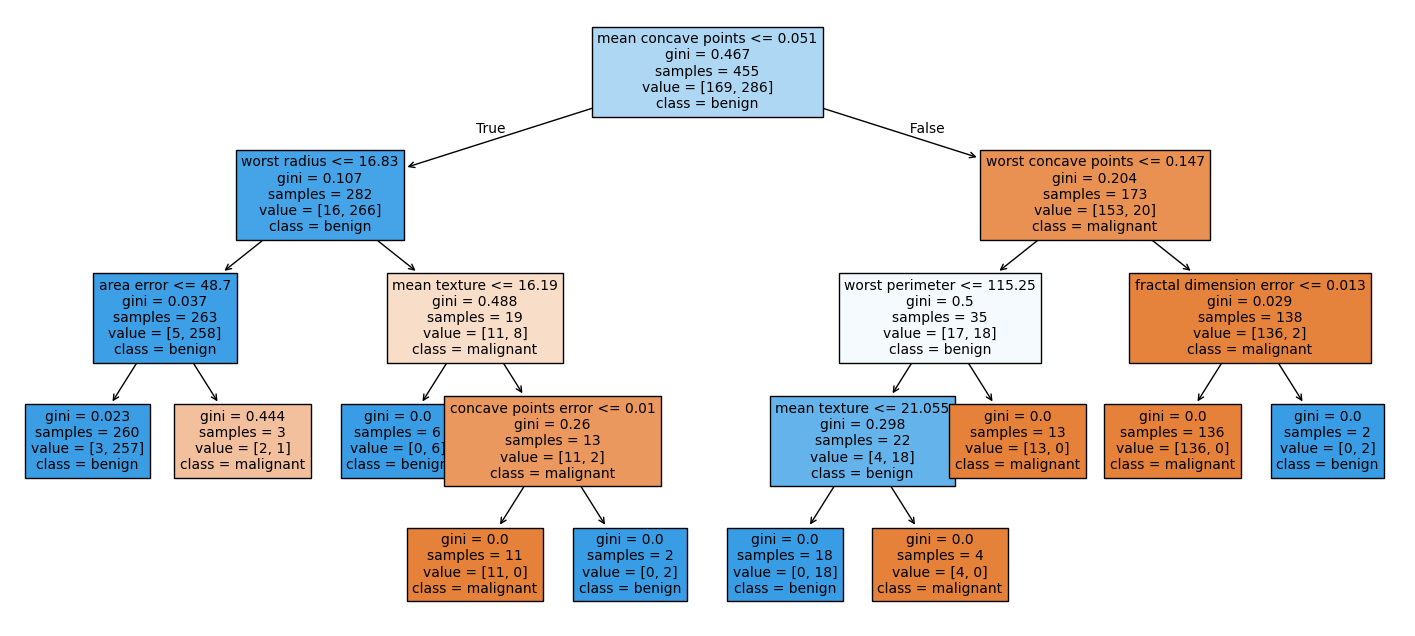

In [37]:
plt.figure(figsize=(18,8))

plot_tree(
    post_tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    fontsize=10
)

plt.show()

In [ ]:
#Revision of what we learned:
# 1. First we saw full tree, there overfitting occured
# 2. Then, we learned Early Stopping of overfitting
# 3. Then, pruning method of overfitting

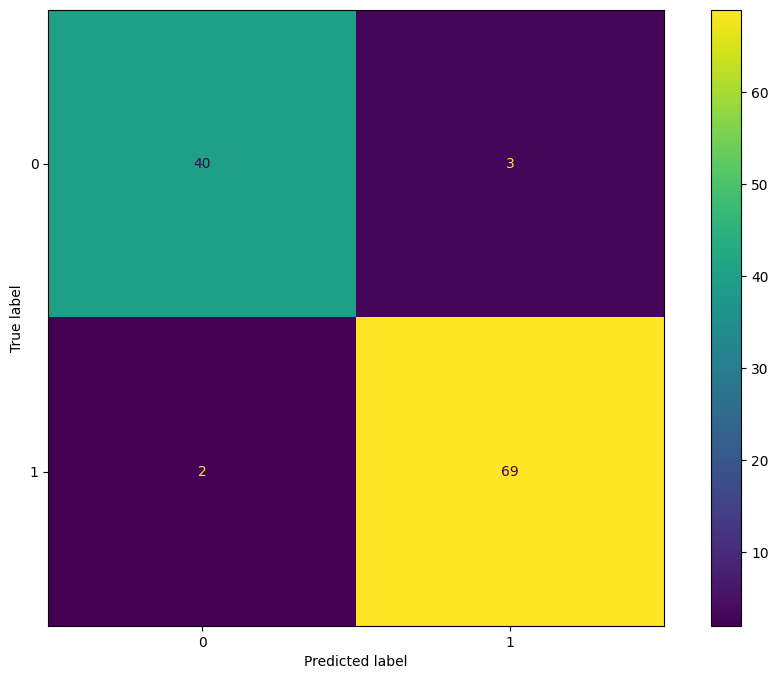

In [42]:
pred=post_tree.predict(X_test)
cm=confusion_matrix(y_test,pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [43]:
print(classification_report(
    y_test,
    pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

